In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
d=pd.read_csv("Telco_customer_churn.csv")
display(d)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
d.shape

(7043, 33)

In [5]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
d["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

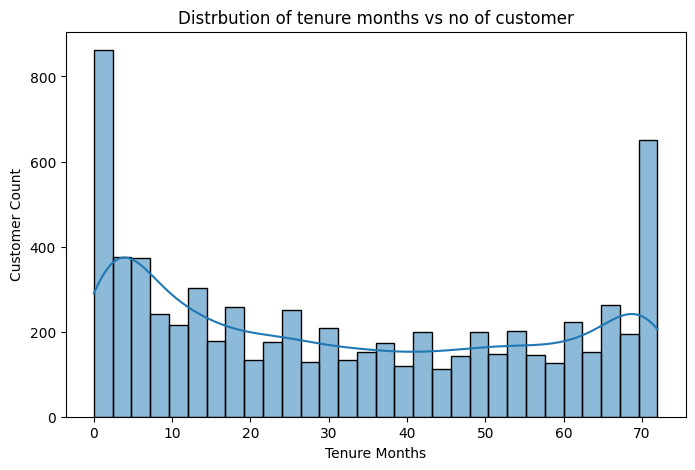

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(d['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distrbution of tenure months vs no of customer')
plt.show()

In [8]:
d["Tenure Months"].max()

np.int64(72)

In [9]:
d['Tenure Months'].min()

np.int64(0)

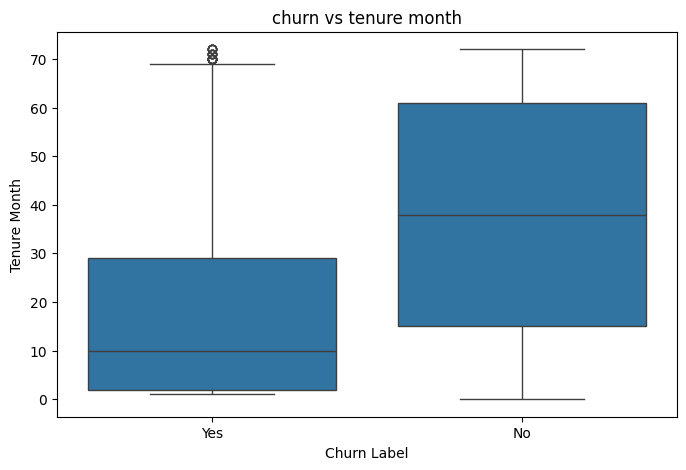

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=d)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Month')
plt.title('churn vs tenure month')
plt.show()

In [11]:
d['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

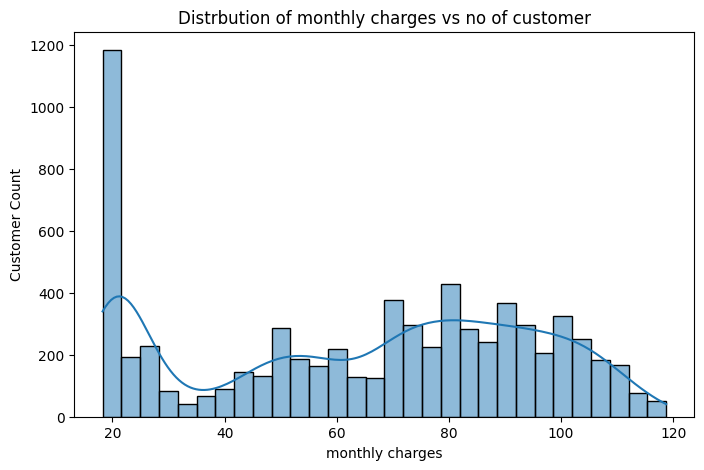

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(d['Monthly Charges'], bins=30, kde=True)
plt.xlabel('monthly charges')
plt.ylabel('Customer Count')
plt.title('Distrbution of monthly charges vs no of customer')
plt.show()

In [13]:
d['Monthly Charges'].max()

np.float64(118.75)

In [14]:
d['Monthly Charges'].min()

np.float64(18.25)

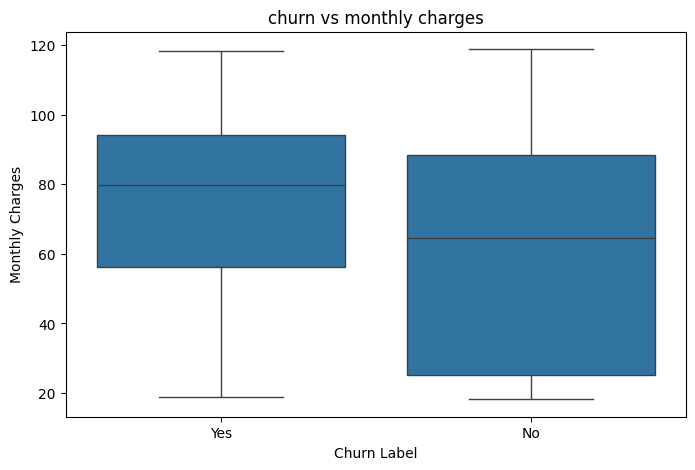

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=d)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('churn vs monthly charges')
plt.show()

In [16]:
d[d['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75]) ##idk

0.25    56.15
0.50    79.65
0.75    94.20
Name: Monthly Charges, dtype: float64

In [17]:
d[d['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75]) ##idk

0.25    25.100
0.50    64.425
0.75    88.400
Name: Monthly Charges, dtype: float64

In [18]:
d['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

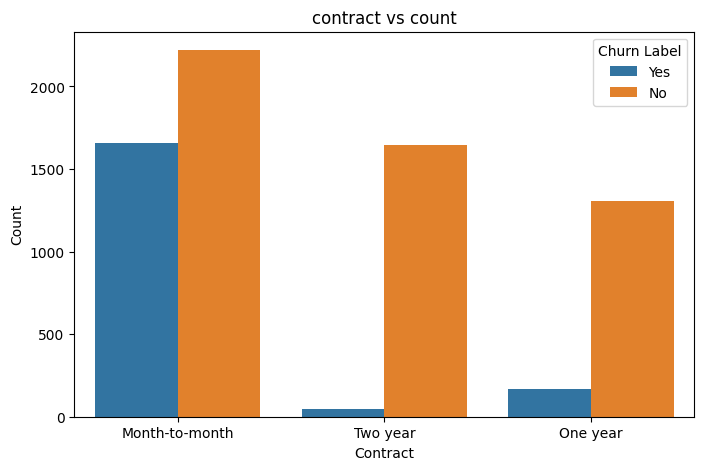

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=d)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('contract vs count')
plt.show()

In [20]:
d['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [21]:
d['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

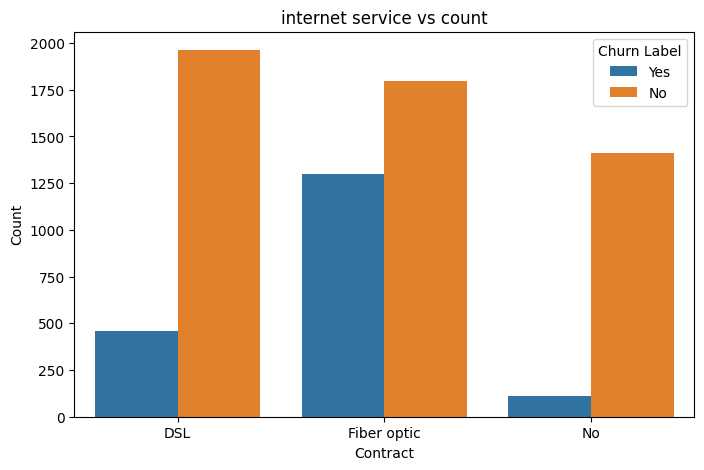

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=d)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('internet service vs count')
plt.show()

In [23]:
d['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

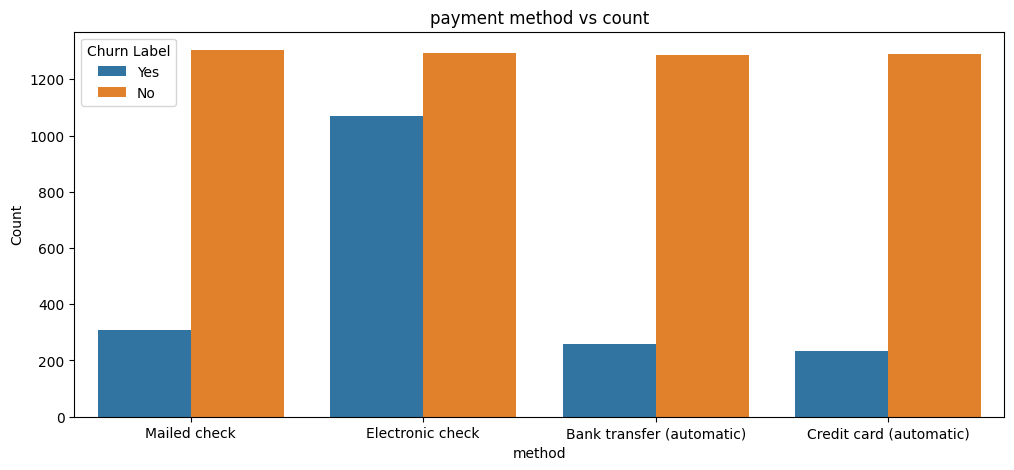

In [24]:
plt.figure(figsize=(12,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=d)
plt.xlabel('method')
plt.ylabel('Count')
plt.title('payment method vs count')
plt.show()

In [25]:
d['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

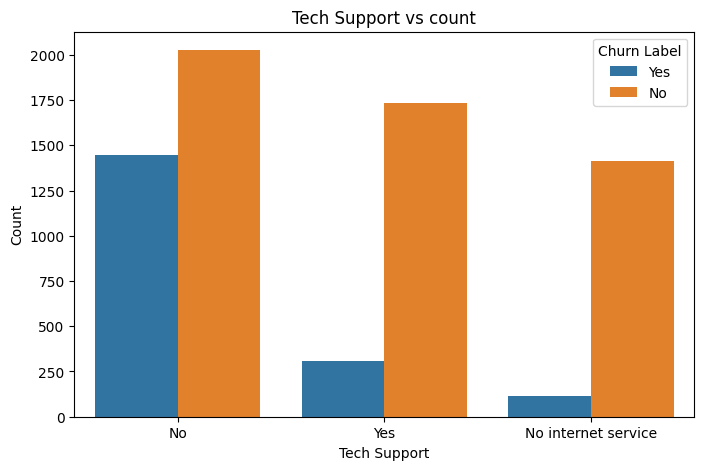

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=d)
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support vs count')
plt.show()

In [27]:
avg_tenure=d.groupby('Churn Label')['Tenure Months'].mean()
display(avg_tenure)

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [28]:
numeric_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = d[numeric_cols].corr()
display(correlation_matrix)

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [29]:
contract_churn=pd.crosstab(d['Contract'],d['Churn Label'])
display(contract_churn)

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [30]:
contract_churn=pd.crosstab(d['Contract'],d['Churn Label'],normalize='index')
display(contract_churn)

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


# data cleaning

In [31]:
d['Total Charges']

0        108.15
1        151.65
2         820.5
3       3046.05
4        5036.3
         ...   
7038     1419.4
7039     1990.5
7040     7362.9
7041     346.45
7042     6844.5
Name: Total Charges, Length: 7043, dtype: object

In [32]:
d['Total Charges'].isnull().sum()

np.int64(0)

In [33]:
d[d['Total Charges'].isnull()]['Tenure Months']

Series([], Name: Tenure Months, dtype: int64)

In [34]:
d[d['Total Charges'].isnull()]['Tenure Months'].shape

(0,)

In [35]:
d['Total Charges']=d['Total Charges'].fillna(0)

In [36]:
d['Total Charges'].isnull().sum()

np.int64(0)

In [37]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [38]:
cols_to_drop = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

d.drop(columns=cols_to_drop, inplace=True)

print(d.columns)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')


In [39]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [40]:
d_encoded=pd.get_dummies(d,drop_first=True)

In [41]:
d_encoded.head()

,Tenure Months,Monthly Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Total Charges_995.35,Total Charges_996.45,Total Charges_996.85,Total Charges_996.95,Total Charges_997.65,Total Charges_997.75,Total Charges_998.1,Total Charges_999.45,Total Charges_999.8,Total Charges_999.9
0,2,53.85,1,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,70.70,1,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8,99.65,1,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,28,104.80,1,False,False,True,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,49,103.70,1,True,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False


In [42]:
x=d_encoded.drop('Churn Value',axis=1)## training data taaki output pata na chale

In [43]:
y=d_encoded['Churn Value']## output check krne k lye

In [44]:
display(x.shape)
display(y.shape)

(7043, 6559)

(7043,)

 # machine learning implementation

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [47]:
x_train.shape

(5634, 6559)

In [48]:
x_test.shape

(1409, 6559)

# random forest classifier ( ensemble learning technique) = we take the group of decision tree

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [51]:
rf_model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [52]:
y_pred=rf_model.predict(x_test)

In [53]:
display(y_pred)

array([0, 0, 0, ..., 1, 0, 1], shape=(1409,))

In [54]:
from sklearn.metrics import accuracy_score

In [55]:
accuracy=accuracy_score(y_test,y_pred)

In [56]:
print(accuracy)

0.7991483321504613


In [57]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.70      0.52      0.59       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



# approach 1

In [59]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(x_train,y_train)
y_pred_balanced=rf_balanced.predict(x_test)
accuracy_balanced=accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test,y_pred_balanced)
print(accuracy_balanced,cm_balanced)
print(classification_report(y_test,y_pred_balanced))

0.7899219304471257 [[832 177]
 [119 281]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1009
           1       0.61      0.70      0.66       400

    accuracy                           0.79      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.80      0.79      0.79      1409



# apporach 2: hyperparameter tuning

In [60]:
rf_tunned = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tunned.fit(x_train,y_train)
y_pred_tunned = rf_tunned.predict(x_test)
print(classification_report(y_test, y_pred_tunned))

              precision    recall  f1-score   support

           0       0.91      0.65      0.76      1009
           1       0.49      0.83      0.61       400

    accuracy                           0.70      1409
   macro avg       0.70      0.74      0.69      1409
weighted avg       0.79      0.70      0.72      1409



# approach 3 feature importance analysis

In [62]:
feature_importance =pd.DataFrame({
    'featurs' : x.columns,
    'importance' : rf_tunned.feature_importances_
})
feature_importance = feature_importance.sort_values(by='importance', ascending=False)
print(feature_importance)

                                  featurs  importance
0                           Tenure Months    0.075862
24                      Contract_Two year    0.070429
27        Payment Method_Electronic check    0.058443
9            Internet Service_Fiber optic    0.058196
21   Streaming Movies_No internet service    0.053778
..                                    ...         ...
584                 Total Charges_1302.65    0.000000
588                 Total Charges_1304.85    0.000000
590                  Total Charges_1306.3    0.000000
593                  Total Charges_1308.4    0.000000
43                   Total Charges_1007.8    0.000000

[6559 rows x 2 columns]


In [63]:
print(feature_importance.tail(15))

                   featurs  importance
568   Total Charges_1296.8         0.0
609  Total Charges_1319.85         0.0
610  Total Charges_1319.95         0.0
575   Total Charges_130.15         0.0
576   Total Charges_130.25         0.0
577    Total Charges_130.5         0.0
578   Total Charges_130.55         0.0
579   Total Charges_130.75         0.0
614   Total Charges_1321.3         0.0
615  Total Charges_1322.55         0.0
584  Total Charges_1302.65         0.0
588  Total Charges_1304.85         0.0
590   Total Charges_1306.3         0.0
593   Total Charges_1308.4         0.0
43    Total Charges_1007.8         0.0


In [64]:
dropping = ['Phone Service_Yes', 'Multiple Lines_No phone service','Streaming TV_Yes','Streaming Movies_Yes','Device Protection_No internet service']
x_selected = x.drop(dropping,axis=1)

In [65]:
x_train_sel, x_test_sel, y_train_sel, y_test_sel = train_test_split(
    x_selected, y, test_size=0.20, random_state=42)

In [66]:
rf_selected = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(x_train_sel,y_train_sel)
y_pred_sel = rf_selected.predict(x_test_sel)
print(classification_report(y_test_sel, y_pred_sel))

              precision    recall  f1-score   support

           0       0.92      0.66      0.77      1009
           1       0.50      0.85      0.63       400

    accuracy                           0.71      1409
   macro avg       0.71      0.75      0.70      1409
weighted avg       0.80      0.71      0.73      1409



# customer segmentation

In [67]:
y_prob = rf_selected.predict_proba(x_selected)
churn_probability = y_prob[:,1]

segmentation_data = pd.DataFrame({
    'Tenure Months': d['Tenure Months'],
    'Monthly Charges': d['Monthly Charges'],
    'Total Charges': d['Total Charges'],
    'Churn Probability': churn_probability
})

segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.527989
1,2,70.70,151.65,0.603363
2,8,99.65,820.5,0.596042
3,28,104.80,3046.05,0.525877
4,49,103.70,5036.3,0.515151


# implementation of K-means

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [69]:
print(segmentation_data.dtypes)

Tenure Months          int64
Monthly Charges      float64
Total Charges         object
Churn Probability    float64
dtype: object


In [70]:
import numpy as np

# Blank spaces ko NaN banao
segmentation_data['Total Charges'] = segmentation_data['Total Charges'].replace(' ', np.nan)

# Numeric mein convert karo
segmentation_data['Total Charges'] = pd.to_numeric(
    segmentation_data['Total Charges'],
    errors='coerce'
)

# Missing values ko median se fill karo
segmentation_data['Total Charges'] = segmentation_data['Total Charges'].fillna(
    segmentation_data['Total Charges'].median()
)

# Check datatype
print(segmentation_data.dtypes)

Tenure Months          int64
Monthly Charges      float64
Total Charges        float64
Churn Probability    float64
dtype: object


In [71]:
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.95967407  0.49021322]
 [-1.23672422  0.19736523 -0.9404697   1.1103621 ]
 [-0.99240204  1.1595457  -0.64518597  1.05013257]
 [-0.17799476  1.33071079  0.33734927  0.47283666]
 [ 0.67713287  1.29415125  1.21600434  0.38459006]]


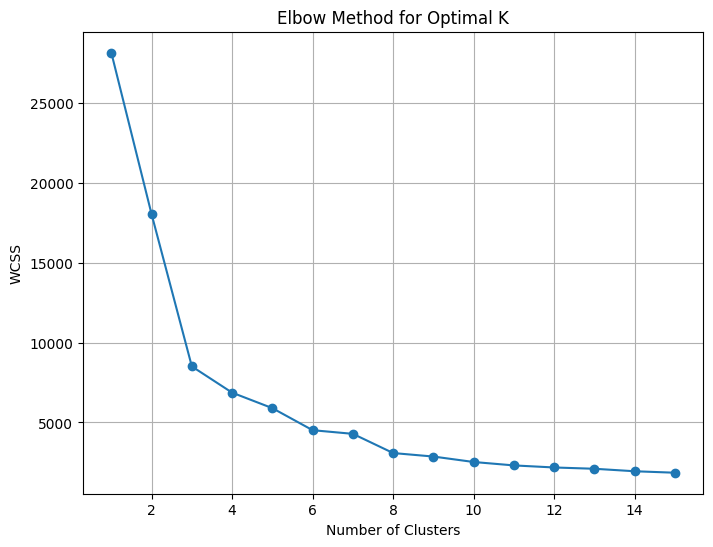

In [72]:
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Replace NaN values with the column mean
imputer = SimpleImputer(strategy='mean')
scaled_data = imputer.fit_transform(scaled_data)

# Elbow Method
wcss = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 16), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [73]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [74]:
segmentation_data['Cluster'] = clusters

In [75]:
display(segmentation_data)

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.527989,2
1,2,70.70,151.65,0.603363,2
2,8,99.65,820.50,0.596042,2
3,28,104.80,3046.05,0.525877,2
4,49,103.70,5036.30,0.515151,1
...,...,...,...,...,...
7038,72,21.15,1419.40,0.270181,0
7039,24,84.80,1990.50,0.408490,2
7040,72,103.20,7362.90,0.437535,1
7041,11,29.60,346.45,0.521270,2


In [76]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [77]:
print(cluster_summary)

         Tenure Months  Monthly Charges  Total Charges  Churn Probability
Cluster                                                                  
0            31.534503        23.306023     772.882310           0.299957
1            58.208975        88.681896    5162.506159           0.467533
2            13.646078        70.159918     985.469175           0.563191


In [78]:
cluster_name = {
    0:"Budget Loyal customer",
    1:"High risk customer",
    2:"Loyal premium customer"
}

In [79]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_name)

In [80]:
display(segmentation_data)

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.527989,2,Loyal premium customer
1,2,70.70,151.65,0.603363,2,Loyal premium customer
2,8,99.65,820.50,0.596042,2,Loyal premium customer
3,28,104.80,3046.05,0.525877,2,Loyal premium customer
4,49,103.70,5036.30,0.515151,1,High risk customer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.270181,0,Budget Loyal customer
7039,24,84.80,1990.50,0.408490,2,Loyal premium customer
7040,72,103.20,7362.90,0.437535,1,High risk customer
7041,11,29.60,346.45,0.521270,2,Loyal premium customer


<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

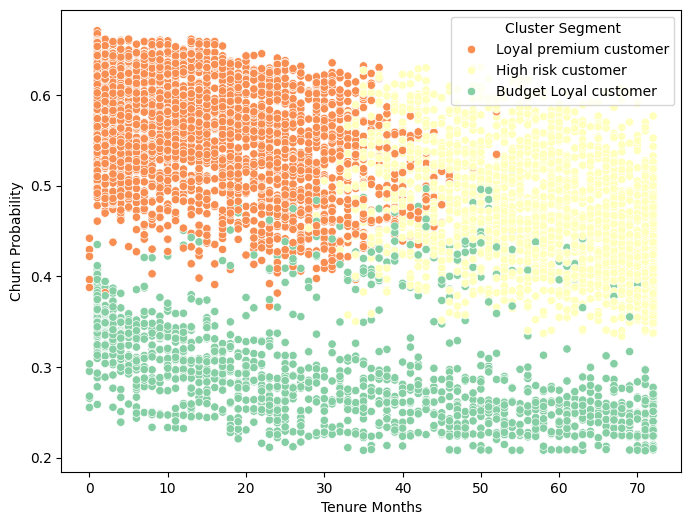

In [81]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data,palette='Spectral')

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

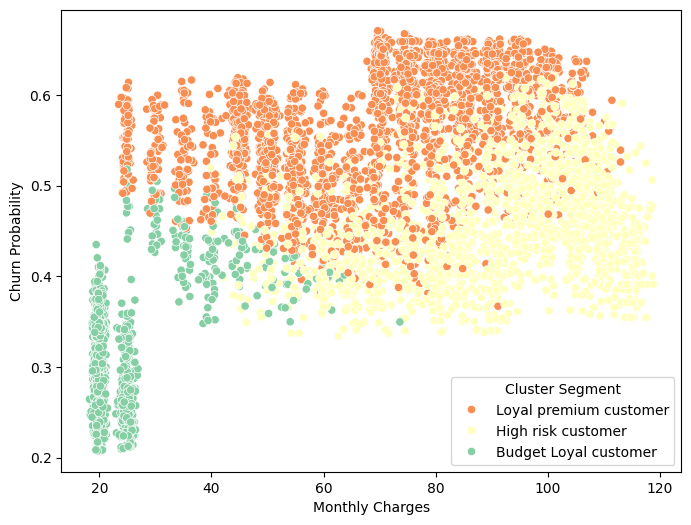

In [82]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data,palette='Spectral')